# Étape 5 — Fonctions d'activation d'un MLP

Le boosting reste meilleur sur ce tabulaire ; ce MLP sert à comparer les fonctions d'activation. Même architecture (deux couches 64-32), seule l'activation change (`identity` / `logistic` / `tanh` / `relu`). Le calcul tourne dans `src/run_mlp_activations.py`, je relis ici les résultats.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
OUTPUT = PROJECT_ROOT / 'output'
res = pd.read_csv(OUTPUT / 'mlp_activation_results.csv')
res.round(4)

,activation,auc,recall_minority,business_cost,n_iter,best_val_score
0,identity,0.7543,0.0237,9480,59,0.9192
1,logistic,0.7160,0.0000,9690,27,0.9194
2,tanh,0.7193,0.0454,9330,31,0.9160
3,relu,0.6999,0.0175,9539,27,0.9177


## Ce que fait chaque fonction d'activation

- `identity` : pas de non-linéarité (le réseau se réduit à un modèle linéaire), c'est mon témoin.
- `logistic` (sigmoïde) : écrase dans [0, 1], sujette au gradient qui s'évanouit.
- `tanh` : centrée en 0, en général mieux que la sigmoïde.
- `relu` : linéaire par morceaux, rapide, le défaut moderne.

## Comparaison des métriques

L'AUC est indépendante du seuil, c'est ma métrique de comparaison principale ici. Le coût métier est donné au seuil 0.5 à titre indicatif.

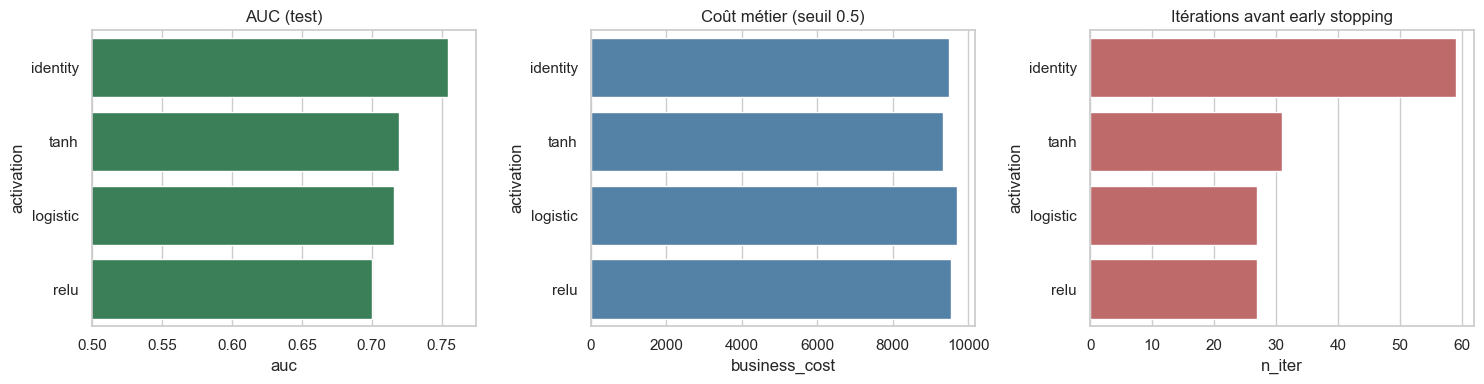

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = res.sort_values('auc', ascending=False)['activation']
sns.barplot(data=res, x='auc', y='activation', order=order, ax=axes[0], color='seagreen')
axes[0].set_xlim(0.5, res.auc.max() + 0.02); axes[0].set_title('AUC (test)')
sns.barplot(data=res, x='business_cost', y='activation', order=order, ax=axes[1], color='steelblue')
axes[1].set_title('Coût métier (seuil 0.5)')
sns.barplot(data=res, x='n_iter', y='activation', order=order, ax=axes[2], color='indianred')
axes[2].set_title('Itérations avant early stopping')
plt.tight_layout(); plt.show()

## Courbes de perte

La vitesse de descente de la perte d'entraînement illustre la qualité de propagation du gradient selon l'activation.

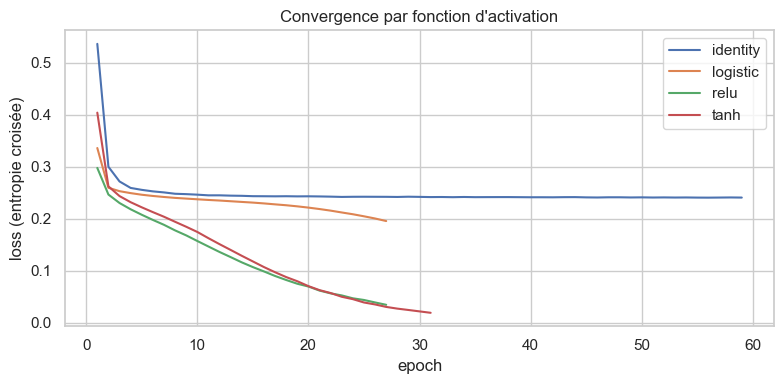

In [3]:
loss = pd.read_csv(OUTPUT / 'mlp_loss_curves.csv')
fig, ax = plt.subplots(figsize=(8, 4))
for act, g in loss.groupby('activation'):
    ax.plot(g.epoch, g.loss, label=act)
ax.set_xlabel('epoch'); ax.set_ylabel('loss (entropie croisée)')
ax.set_title("Convergence par fonction d'activation"); ax.legend()
plt.tight_layout(); plt.show()

In [4]:
best = res.sort_values('auc', ascending=False).iloc[0]
worst = res.sort_values('auc').iloc[0]
print(f"Meilleure activation : {best['activation']} (AUC {best['auc']:.4f}).")
print(f"La moins bonne : {worst['activation']} (AUC {worst['auc']:.4f}).")

Meilleure activation : identity (AUC 0.7543).
La moins bonne : relu (AUC 0.6999).


## Choix retenu et analyse

Constat : aucune activation non-linéaire ne dépasse le témoin `identity` (linéaire) sur l'AUC. Parmi les non-linéaires, `tanh` arrive en tête, devant `logistic` et `relu`.

Impact des activations : sur cette entrée à très haute dimension et creuse (779 colonnes, beaucoup de one-hot et de NaN imputés), le signal exploitable est largement linéaire une fois les features agrégées. Un MLP peu profond n'y gagne rien et converge même un peu moins bien ; les variantes non-linéaires s'arrêtent tôt (early stopping autour de 27-31 itérations) parce que leur score de validation interne plafonne vite.

Décision : si l'on devait garder un MLP, je retiendrais `tanh` — la meilleure activation non-linéaire, centrée en 0 et au gradient mieux propagé que la sigmoïde. Mais le constat global est qu'un MLP n'est pas compétitif ici face au boosting de l'Étape 4, ce qui est cohérent avec la littérature sur les données tabulaires. La régularisation (pénalité L2 `alpha=1e-3` + early stopping sur une fraction de validation interne) limite le surapprentissage de chaque variante.

Le coût métier au seuil 0.5 reste élevé pour toutes les activations (un MLP non pondéré prédit surtout la classe majoritaire) : il se réglerait par le seuil comme à l'Étape 4. Ici l'objet est la comparaison d'activations, donc je m'appuie sur l'AUC, indépendante du seuil.